# Solution of Problem Set 2

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Exercise 2.1: The Hückel Method

In the Hückel method, every carbon atom contributing one $p_z$ orbital is represented by one basis function. The Hückel matrix $H$ has one row and one column per carbon atom. In the dimensionless form used here,

$$
H_{ij} = \begin{cases}
0 & i = j \\
-1 & \text{carbon atoms } i \text{ and } j \text{ are bonded} \\
0 & \text{otherwise}
\end{cases}
$$

This corresponds to setting the Coulomb integral $\alpha = 0$ and the resonance integral $\beta = -1$.
For benzene, numbering the carbon atoms around the ring, the Hückel matrix is

$$
H_\mathrm{benzene} =
\begin{pmatrix}
0 & -1 & 0 & 0 & 0 & -1 \\
-1 & 0 & -1 & 0 & 0 & 0 \\
0 & -1 & 0 & -1 & 0 & 0 \\
0 & 0 & -1 & 0 & -1 & 0 \\
0 & 0 & 0 & -1 & 0 & -1 \\
-1 & 0 & 0 & 0 & -1 & 0
\end{pmatrix} \, .
$$

**(a) Solve for the eigenvalues and eigenvectors of benzene. Print all eigenvalues and the coefficients of the three occupied molecular orbitals.**<br>
*Hint: Use `np.linalg.eigh`. Eigenvectors in degenerate subspaces may differ by signs or rotations.*

In [2]:
benzene_huckel = np.array([
    [ 0, -1,  0,  0,  0, -1],
    [-1,  0, -1,  0,  0,  0],
    [ 0, -1,  0, -1,  0,  0],
    [ 0,  0, -1,  0, -1,  0],
    [ 0,  0,  0, -1,  0, -1],
    [-1,  0,  0,  0, -1,  0],
], dtype=float)

# SOLUTION-START
eigvals_benzene, eigvecs_benzene = np.linalg.eigh(benzene_huckel)
occupied_benzene = eigvecs_benzene[:, :3]


# SOLUTION-END

print('eigenvalues:')
print(eigvals_benzene)
print('occupied MO coefficients:')
print(occupied_benzene)

eigenvalues:
[-2. -1. -1.  1.  1.  2.]
occupied MO coefficients:
[[ 0.40824829 -0.57558038  0.04517255]
 [ 0.40824829 -0.32691077 -0.47588096]
 [ 0.40824829  0.24866961 -0.52105351]
 [ 0.40824829  0.57558038 -0.04517255]
 [ 0.40824829  0.32691077  0.47588096]
 [ 0.40824829 -0.24866961  0.52105351]]


The total electronic energy in the framework of the Hückel method is given by 

$$
E_\mathrm{total} = \sum_{i=1}^{N_\mathrm{orb}} f_i \varepsilon_i \, ,
$$

where $\varepsilon_i$ are the eigenvalues of the Hückel matrix, 
ordered from lowest to highest, and $f_i$ are the occupation numbers of the 
corresponding molecular orbitals, which are 2 for doubly occupied orbitals,
1 for singly occupied orbitals, and 0 for unoccupied orbitals. 

**(b) Calculate the electronic energy of benzene in the same dimensionless units.**<br>

In [3]:
# SOLUTION-START
energy_benzene = 2 * np.sum(eigvals_benzene[:3])
# SOLUTION-END

print('electronic energy:', energy_benzene)

electronic energy: -7.999999999999998


In computational chemistry, a common format for exchanging molecular structures is the XYZ file format. 
The first line contains the number of atoms, the second line is a comment, 
and the subsequent lines contain the element symbol and Cartesian coordinates of each atom.

The following function accepts the path to an XYZ file and returns a list
of shape `(N, )` containing the element symbols and a NumPy array of shape 
`(N, 3)` containing the Cartesian coordinates, where `N` is the number of atoms.
You do not need to understand the details of this implementation.

In [4]:
def read_xyz(filename):
    with open(filename, 'r') as f:
        num_atoms = int(f.readline().strip())
        _comment = f.readline().strip()
        symbols = []
        coordinates = []
        for _ in range(num_atoms):
            line = f.readline().strip().split()
            symbols.append(line[0])
            coordinates.append([float(x) for x in line[1:4]])
    return symbols, np.array(coordinates)

Now, we shall explore a more interesting system, the phenalenyl cation ({chem}`C13H9+`).
Please download {download}`/assets/data/spectral_analysis/phenalenyl.xyz` 
and place it in the same directory as this notebook.

**(c) Construct the Hückel matrix for the phenalenyl cation.**<br>
*Hint: First filter out the coordinates of the carbon atoms. Then, in the nested loop,
check whether the two atoms have the same index, and if not, check if they are bonded.
You can check for bonding by first calculating the distance between the two atoms and then 
comparing it with `BONDED_THRESHOLD`.*

In [5]:
BONDED_THRESHOLD = 1.5  # Angstrom

xyz_filename = 'phenalenyl.xyz'
# INSTRUCTOR-ONLY-START
xyz_filename = '../assets/data/spectral_analysis/phenalenyl.xyz'
# INSTRUCTOR-ONLY-END

symbols, coordinates = read_xyz(xyz_filename)
natoms = len(symbols)
ncarbons = symbols.count('C')

carbon_coordinates = []
# SOLUTION-START
for i in range(natoms):
    if symbols[i] == 'C':
        carbon_coordinates.append(coordinates[i])
# SOLUTION-END

carbon_coordinates = np.array(carbon_coordinates)
phenalenyl_huckel = np.zeros((ncarbons, ncarbons), dtype=float)
for i in range(ncarbons):
    for j in range(ncarbons):
        # SOLUTION-START
        distance = np.linalg.norm(carbon_coordinates[i] - carbon_coordinates[j])
        if i == j:
            phenalenyl_huckel[i, j] = 0.0
        elif distance < BONDED_THRESHOLD:
            phenalenyl_huckel[i, j] = -1.0
        # SOLUTION-END

print('phenalenyl Hückel matrix:')
print(phenalenyl_huckel)

phenalenyl Hückel matrix:
[[ 0. -1. -1. -1.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [-1.  0.  0.  0. -1.  0.  0.  0.  0.  0.  0.  0. -1.]
 [-1.  0.  0.  0.  0. -1.  0.  0.  0.  0. -1.  0.  0.]
 [-1.  0.  0.  0.  0.  0. -1.  0.  0.  0.  0. -1.  0.]
 [ 0. -1.  0.  0.  0.  0.  0. -1.  0.  0.  0.  0.  0.]
 [ 0.  0. -1.  0.  0.  0.  0.  0. -1.  0.  0.  0.  0.]
 [ 0.  0.  0. -1.  0.  0.  0.  0.  0. -1.  0.  0.  0.]
 [ 0.  0.  0.  0. -1.  0.  0.  0.  0.  0. -1.  0.  0.]
 [ 0.  0.  0.  0.  0. -1.  0.  0.  0.  0.  0. -1.  0.]
 [ 0.  0.  0.  0.  0.  0. -1.  0.  0.  0.  0.  0. -1.]
 [ 0.  0. -1.  0.  0.  0.  0. -1.  0.  0.  0.  0.  0.]
 [ 0.  0.  0. -1.  0.  0.  0.  0. -1.  0.  0.  0.  0.]
 [ 0. -1.  0.  0.  0.  0.  0.  0.  0. -1.  0.  0.  0.]]


**(d) Solve for the eigenvalues and eigenvectors of the phenalenyl Hückel matrix. Print all eigenvalues and the coefficients of the LUMO.**<br>
*Hint: The phenalenyl cation has a charge of +1.*

In [6]:
# SOLUTION-START
eigvals_phenalenyl, eigvecs_phenalenyl = np.linalg.eigh(phenalenyl_huckel)
lumo_index = (ncarbons - 1) // 2
lumo_coefficients = eigvecs_phenalenyl[:, lumo_index]
# SOLUTION-END

print('eigenvalues:')
print(eigvals_phenalenyl)
print('LUMO index:', lumo_index)
print('LUMO coefficients:')
print(lumo_coefficients)

eigenvalues:
[-2.44948974e+00 -1.73205081e+00 -1.73205081e+00 -1.00000000e+00
 -1.00000000e+00 -1.00000000e+00  2.22044605e-16  1.00000000e+00
  1.00000000e+00  1.00000000e+00  1.73205081e+00  1.73205081e+00
  2.44948974e+00]
LUMO index: 6
LUMO coefficients:
[-1.52669613e-33  1.41067106e-16 -3.87700693e-18 -1.37190099e-16
 -4.08248290e-01 -4.08248290e-01 -4.08248290e-01 -1.72130175e-16
  2.62139520e-16 -9.00093454e-17  4.08248290e-01  4.08248290e-01
  4.08248290e-01]


**(e) Use the prepared plotting code below to visualise the HOMO of the phenalenyl cation.**<br>
*Hint: The HOMO is the orbital directly below the LUMO.*

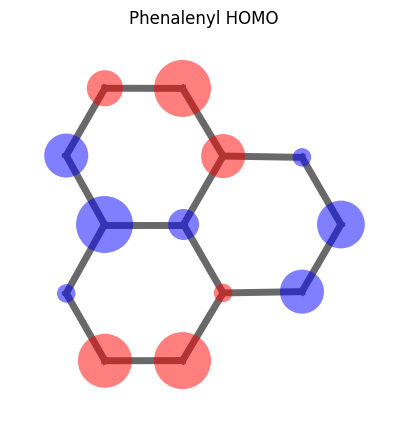

In [7]:
def plot_huckel_orbital(coords, coefficients, title='Hückel molecular orbital'):
    x = coords[:, 0]
    y = coords[:, 1]
    coefficients = np.asarray(coefficients)
    sizes = 4000 * np.abs(coefficients)
    colors = ['r' if c > 0 else 'b' for c in coefficients]

    fig, ax = plt.subplots(figsize=(5, 5))

    for i in range(len(coords)):
        for j in range(i + 1, len(coords)):
            if np.linalg.norm(coords[i] - coords[j]) < BONDED_THRESHOLD:
                ax.plot([x[i], x[j]], [y[i], y[j]], 
                        color='dimgrey', linewidth=5, zorder=1)

    ax.scatter(
        x,
        y,
        s=sizes,
        c=colors,
        edgecolor='none',
        linewidth=0.0,
        zorder=2,
        alpha=0.5,
    )
    
    LIM_PAD = 1.0
    xmin = x.min() - LIM_PAD
    xmax = x.max() + LIM_PAD
    ymin = y.min() - LIM_PAD
    ymax = y.max() + LIM_PAD

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title)
    plt.show()


# SOLUTION-START
homo_coefficients = eigvecs_phenalenyl[:, lumo_index - 1]
plot_huckel_orbital(carbon_coordinates, homo_coefficients, title='Phenalenyl HOMO')
# SOLUTION-END

## Exercise 2.2: Molecular Alignment with the Kabsch Algorithm

It is a common task for chemists to compare different geometries of the same molecule, 
*e.g.*, between its gas-phase and solution geometries, its ground-state and excited-state geometries, 
two conformers, structures optimised with different methods, or snapshots from a molecular dynamics trajectory. 
A natural first idea is to compare the Cartesian coordinates atom by atom. 

We will work with three water geometries:

- {download}`/assets/data/spectral_analysis/water0.xyz`
- {download}`/assets/data/spectral_analysis/water1.xyz`
- {download}`/assets/data/spectral_analysis/water2.xyz`

Please download all three files and place them in the same directory as this notebook.

A common metric for comparing two geometries is the root-mean-square deviation (RMSD),

$$
\mathrm{RMSD} = \sqrt{\frac{1}{N} \sum_{i=1}^{N} \lVert \vec{p}_i - \vec{q}_i \rVert^2} \, ,
$$

where $\vec{p}_i$ and $\vec{q}_i$ are the coordinates of atom $i$ in the two geometries,
and $N$ is the total number of atoms.
The atom order must be the same in both coordinate arrays. 
In this exercise, we ignore atomic masses and treat all atoms equally.

**(a) Read the three water geometries and implement a function `rmsd(coords_p, coords_q)` 
that calculates the RMSD between two `(N, 3)` coordinate arrays. 
Print the RMSD between `water0_coordinates` and the other two sets of coordinates.**<br>

In [8]:
water0_filename = 'water0.xyz'
water1_filename = 'water1.xyz'
water2_filename = 'water2.xyz'
# INSTRUCTOR-ONLY-START
water0_filename = '../assets/data/spectral_analysis/water0.xyz'
water1_filename = '../assets/data/spectral_analysis/water1.xyz'
water2_filename = '../assets/data/spectral_analysis/water2.xyz'
# INSTRUCTOR-ONLY-END

_, water0_coordinates = read_xyz(water0_filename)
_, water1_coordinates = read_xyz(water1_filename)
_, water2_coordinates = read_xyz(water2_filename)


def rmsd(coords_p, coords_q):
    # SOLUTION-START
    differences = coords_p - coords_q
    squared_distances = np.sum(differences ** 2, axis=1)
    return np.sqrt(np.mean(squared_distances))
    # SOLUTION-END


# SOLUTION-START
rmsd_01 = rmsd(water0_coordinates, water1_coordinates)
rmsd_02 = rmsd(water0_coordinates, water2_coordinates)
# SOLUTION-END

print('RMSD water0 vs. water1:', rmsd_01)
print('RMSD water0 vs. water2:', rmsd_02)

RMSD water0 vs. water1: 0.38645547889332177
RMSD water0 vs. water2: 3.0124215936518577


It appears that `water1_coordinates` is more similar to `water0_coordinates` than `water2_coordinates` is, 
as the RMSD between `water0_coordinates` and `water1_coordinates` is smaller.
This result, however, can be misleading, since Cartesian coordinates encode arbitrary translations and rotations. 
For us chemists, the geometry of a molecule is invariant to translations and rotations in space.

In this exercise, we will implement the [*Kabsch algorithm*](wiki:Kabsch_algorithm) as an alignment procedure:
we first remove translations by shifting each geometry to its centroid, and then find the optimal rotation.
The first step is therefore to shift each geometry to its centroid.

The centroid is defined as
$$
\vec{c} = \frac{1}{N} \sum_{i=1}^{N} \vec{r}_i \, .
$$

**(b) Implement the function `centre_coordinates(coords)` that returns the centroid and the coordinates shifted to the centroid. 
Then apply it to all three water geometries.**<br>
*Hint: The `axis` argument of `np.mean` may be useful.*

In [9]:
def centre_coordinates(coords):
    # SOLUTION-START
    centroid = np.mean(coords, axis=0)
    centred_coords = coords - centroid
    return centroid, centred_coords
    # SOLUTION-END


# SOLUTION-START
water0_centroid, water0_centred = centre_coordinates(water0_coordinates)
water1_centroid, water1_centred = centre_coordinates(water1_coordinates)
water2_centroid, water2_centred = centre_coordinates(water2_coordinates)
# SOLUTION-END

print('water0 centroid:', water0_centroid)
print('water1 centroid:', water1_centroid)
print('water2 centroid:', water2_centroid)
print('water2 coordinates after centring:')
print(water2_centred)

water0 centroid: [ 0.          0.         -0.23983667]
water1 centroid: [0. 0. 0.]
water2 centroid: [-2.78021     0.23207667  0.63131333]
water2 coordinates after centring:
[[ 0.15387    -0.26995667  0.26004667]
 [ 0.19849    -0.26068667 -0.70373333]
 [-0.35236     0.53064333  0.44368667]]


The second step of the Kabsch algorithm is to find the optimal rotation 
that aligns one centred geometry onto another.
Suppose $\bm{P}$ and $\bm{Q}$ are $N\times 3$ arrays 
containing the centred Cartesian coordinates of two geometries.
Then we define the matrix $\bm{H} = \bm{P}^\intercal \bm{Q}$ and obtain its 
{abbr}`SVD (singular value decomposition)` as $\bm{H} = \bm{U} \bm{\Sigma} \bm{V}^\intercal$.
The Kabsch rotation matrix $\bm{R}$ is then defined by

$$
\bm{R} = \bm{U} \begin{pmatrix}
1 & 0 & 0 \\
0 & 1 & 0 \\
0 & 0 & d
\end{pmatrix} \bm{V}^\intercal \, ,
$$

where $d = \det(\bm{U} \bm{V}^\intercal)$.

**(c) Implement the function `kabsch_rotation(centred_p, centred_q)` that returns the Kabsch rotation matrix for two centred coordinate arrays.**<br>
*Hint: The diagonal matrix $\mathrm{diag}(1, 1, d)$ can be constructed using [`np.diag`](https://numpy.org/doc/stable/reference/generated/numpy.diag.html). The determinant can be calculated using [`np.linalg.det`](https://numpy.org/doc/stable/reference/generated/numpy.linalg.det.html).*

In [10]:
def kabsch_rotation(centred_p, centred_q):
    # SOLUTION-START
    h_mat = centred_p.T @ centred_q
    u, s, vt = np.linalg.svd(h_mat)

    correction = np.diag([1, 1, np.linalg.det(u @ vt)])

    r_mat = u @ correction @ vt
    return r_mat
    # SOLUTION-END


r_02 = kabsch_rotation(water0_centred, water2_centred)
print('Kabsch rotation matrix for aligning water2 onto water0:')
print(r_02)

Kabsch rotation matrix for aligning water2 onto water0:
[[ 0.36754274 -0.52799776 -0.76559173]
 [ 0.84894207  0.52662015  0.04436859]
 [ 0.37974952 -0.66625038  0.64179493]]


Then, $\bm{Q} \bm{R}^\intercal$ is the optimally rotated geometry of $\bm{Q}$ that best aligns with $\bm{P}$.
Here $\bm{P}$ and $\bm{Q}$ still denote centred coordinates.

**(d) Apply the Kabsch rotation to the pairs `(water0_centred, water1_centred)` and `(water0_centred, water2_centred)`. Compute the RMSD after alignment.**<br>
*Hint: Use `water0_centred` for the RMSD calculation instead of `water0_coordinates`.*

In [11]:
# SOLUTION-START
r_01 = kabsch_rotation(water0_centred, water1_centred)
water1_aligned = water1_centred @ r_01.T
rmsd_01_aligned = rmsd(water0_centred, water1_aligned)

r_02 = kabsch_rotation(water0_centred, water2_centred)
water2_aligned = water2_centred @ r_02.T
rmsd_02_aligned = rmsd(water0_centred, water2_aligned)
# SOLUTION-END

print('RMSD water0 vs. water1 after alignment:', rmsd_01_aligned)
print('RMSD water0 vs. water2 after alignment:', rmsd_02_aligned)

RMSD water0 vs. water1 after alignment: 0.3030283988158352
RMSD water0 vs. water2 after alignment: 1.5778160589119343e-06


After centring and optimal rotation, the RMSD no longer measures where the molecule happened to sit in the coordinate system. In this example, `water2` looked very different from `water0` before alignment because it was translated and rotated, but its RMSD becomes almost zero after Kabsch alignment. By contrast, `water1` still has a noticeable RMSD after alignment, so it represents a genuinely different internal geometry. The important assumption is that the atom ordering is consistent across the coordinate arrays.

## Exercise 2.3: Balancing a Chemical Equation

Balancing chemical equations is a familiar example of an underdetermined linear system. In school, we often solve such systems by inspection. Redox reactions can be harder, and are usually handled with tricks such as balancing oxidation and reduction half-reactions separately, or using the ion-electron method.

As an example, consider the acidic redox reaction between permanganate and iron(II):

$$
a\,\mathrm{MnO_4^-}
+ b\,\mathrm{Fe^{2+}}
+ c\,\mathrm{H_2O}
\rightarrow
d\,\mathrm{Mn^{2+}}
+ e\,\mathrm{Fe^{3+}}
+ f\,\mathrm{H_3O^+}\, .
$$

For this equation to be balanced, each element and the total charge must be conserved. This gives

$$
\begin{align*}
\text{H balance:}      \quad && 2c       &= 3f \\
\text{O balance:}      \quad && 4a + c   &= f \\
\text{Mn balance:}     \quad && a        &= d \\
\text{Fe balance:}     \quad && b        &= e \\
\text{charge balance:} \quad && -a + 2b  &= 2d + 3e + f \, .
\end{align*}
$$


After rearranging, we can write this as the homogeneous linear system

$$
\bm{A}\vec{x} = \vec{0}
$$

with

$$
\vec{x} = (a, b, c, d, e, f)^\intercal \, .
$$

**(a) Construct the matrix `balance_matrix` for conservation of H, O, Mn, Fe, and charge. Also construct the zero vector `b_vec`.**<br>
*Hint: To not spoil the solution from the expected output, a diagnostic matrix-vector product is provided.*

In [12]:
# The columns correspond to: MnO4-, Fe2+, H2O, Mn2+, Fe3+, H3O+
# The rows correspond to: H, O, Mn, Fe, charge
# SOLUTION-START
balance_matrix = np.array([
    [ 0,  0,  2,  0,  0, -3],  # H
    [ 4,  0,  1,  0,  0, -1],  # O
    [ 1,  0,  0, -1,  0,  0],  # Mn
    [ 0,  1,  0,  0, -1,  0],  # Fe
    [-1,  2,  0, -2, -3, -1],  # charge
])
b_vec = np.zeros(5)
# SOLUTION-END

diagnostic_vector = np.array([1, -2, 3, -4, 5, -6])

print('shape of balance_matrix:', balance_matrix.shape)
print('shape of b_vec:', b_vec.shape)
print('diagnostic product:')
print(balance_matrix @ diagnostic_vector)

shape of balance_matrix: (5, 6)
shape of b_vec: (5,)
diagnostic product:
[24 13  5 -7 -6]


**(b) Use [`np.linalg.lstsq`](https://numpy.org/doc/stable/reference/generated/numpy.linalg.lstsq.html) to solve this homogeneous system.**<br>

In [13]:
# SOLUTION-START
solution, residuals, rank, singular_values = np.linalg.lstsq(
    balance_matrix,
    b_vec,
)
# SOLUTION-END

print('solution:', solution)
print('rank:', rank)

solution: [0. 0. 0. 0. 0. 0.]
rank: 5


The solution is mathematically correct, but chemically useless: it is the zero vector. This is expected for a homogeneous system, because the zero vector is always a solution. Since `np.linalg.lstsq` returns the solution with minimal Euclidean norm, it returns the zero vector here.

To obtain stoichiometric coefficients, we need a non-zero solution of the homogeneous system. In other words, we need a vector in the nullspace of `balance_matrix`. The dimension of the nullspace is called the *nullity*. For a matrix with `n` columns,

$$
\mathrm{nullity}(\bm{A}) = n - \mathrm{rank}(\bm{A}) \, .
$$

**(c) Use the rank returned by `np.linalg.lstsq` to calculate the nullity of `balance_matrix`.**

In [14]:
# SOLUTION-START
n_unknowns = balance_matrix.shape[1]
nullity = n_unknowns - rank
# SOLUTION-END

print('number of unknowns:', n_unknowns)
print('nullity:', nullity)

number of unknowns: 6
nullity: 1


With a nullity of 1, all solutions are scalar multiples of a single nullspace vector. We can obtain this vector from the SVD.

:::{note} Nullity and Nullspace
:class: dropdown
The solutions of a homogeneous system form a vector space, called the [*kernel*](wiki:Kernel_(algebra)) or *nullspace* of $\bm{A}$. Its dimension is the nullity of $\bm{A}$.

If the nullity is zero, the only solution is the zero vector, also called the *trivial solution*. If the nullity is greater than zero, there are infinitely many solutions. The right singular vectors corresponding to zero singular values form a basis for the nullspace.

Let these singular vectors be $\vec{v}_{-1}, \vec{v}_{-2}, \ldots, \vec{v}_{-k}$, where $k$ is the nullity. Then any solution of $\bm{A}\vec{x} = \vec{0}$ can be written as
$$
\vec{x} = c_1 \vec{v}_{-1} + c_2 \vec{v}_{-2} + \ldots + c_k \vec{v}_{-k}\,.
$$
In this exercise, the nullity is 1, so $\vec{x} = c \vec{v}_{-1}$.
:::

**(d) Use `np.linalg.svd` to obtain this vector. Rescale it so that the coefficient of $\mathrm{MnO_4^-}$ is 1.**<br>
*Hint: The right singular vectors are stored in the rows of $\bm{V}^\intercal$. The overall sign of a singular vector is arbitrary, so your raw vector may have all signs flipped.*

In [15]:
# SOLUTION-START
u, s, vt = np.linalg.svd(balance_matrix)
raw_coefficients = vt[-1]

coefficients = raw_coefficients / raw_coefficients[0]
# SOLUTION-END

print('raw coefficients:')
print(raw_coefficients)
print('coefficients:')
print(coefficients)

raw coefficients:
[-0.06201737 -0.31008684  0.74420841 -0.06201737 -0.31008684  0.49613894]
coefficients:
[  1.   5. -12.   1.   5.  -8.]


**(e) Interpret the negative coefficients and write down the balanced chemical equation.**<br>

In [16]:

print('The negative coefficients mean that H2O and H3O+ should be moved to the opposite sides.')
print('Balanced equation:')
print('MnO4- + 5 Fe2+ + 8 H3O+ -> Mn2+ + 5 Fe3+ + 12 H2O')

The negative coefficients mean that H2O and H3O+ should be moved to the opposite sides.
Balanced equation:
MnO4- + 5 Fe2+ + 8 H3O+ -> Mn2+ + 5 Fe3+ + 12 H2O
